# Yeast Protein-Protein Interaction Network — Spectral Clustering Benchmark

**COMP702 Dissertation · Milestone 3**

Third in the dataset series (after `01_synthetic.ipynb` and `02_airports.ipynb`):
the same five algorithms, conventions, and three-embedding evaluation, now on a
**biological network with no ground truth**. Cluster quality is judged by internal
indices (Silhouette, Davies-Bouldin) under three embeddings
(`scripts/network_eval.py`), already run for all three real datasets.

| Algorithm | Reference |
|---|---|
| K-Means (baseline) | Lloyd (1957) |
| Unnormalised Spectral Clustering | von Luxburg (2007) |
| Normalised SC — Shi & Malik | Shi & Malik (2000) |
| Normalised SC — Ng, Jordan & Weiss | Ng, Jordan & Weiss (2001) |
| Self-Tuning SC — Zelnik-Manor & Perona | Zelnik-Manor & Perona (2004) |

As on Airports, the graph has no raw feature space, so the **K-Means baseline and
Self-Tuning SC operate on the unnormalised-Laplacian node embedding** and the
three graph-native spectral methods operate on the **adjacency**. The Airports
notebook found that the unnormalised methods degenerate on a hub-and-spoke graph
with degree-1 leaves; a recurring question here is whether the same happens on a
much sparser biological network.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_repo = _here if (_here / "scripts").exists() else _here.parent
sys.path.insert(0, str(_repo))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts import SEED
from scripts.network_datasets import load_yeast
from scripts.selection import select_spectral_k
from scripts.spectral import (kmeans_baseline, unnormalised_spectral, spectral_shi_malik,
                              spectral_ng_jordan_weiss, self_tuning_spectral)
from scripts.network_eval import (build_embeddings, evaluate_multi_embedding,
                                  ranking_consistency, consistency_verdict,
                                  format_comparison_table, EMBEDDINGS)

np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110
print(f"Global seed = {SEED}")

Global seed = 42


## 1. Setup and data loading

Each **node** is a yeast (*Saccharomyces cerevisiae*) protein; each undirected
**edge** is an observed physical interaction between two proteins. The graph is
NetworkRepository's `bio-yeast` in Matrix Market format
(`scripts.network_datasets.load_yeast`), an *unweighted* interaction network. As
on Airports we work with the largest connected component; the cell below reports
whether that step actually removes anything here.

In [2]:
A_raw, nodes_raw, G_raw = load_yeast(largest_component=False)
import networkx as nx
n_comp = nx.number_connected_components(G_raw)
print(f"Raw graph: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges, "
      f"{n_comp} connected component(s).")

A, nodes, G = load_yeast()   # largest connected component
n_nodes, n_edges = A.shape[0], int(A.nnz // 2)
print(f"Used (largest component): {n_nodes} nodes, {n_edges} edges, "
      f"connected = {nx.is_connected(G)}")
if n_nodes == G_raw.number_of_nodes():
    print("=> the network is already a single connected component; nothing was dropped.")

Raw graph: 1458 nodes, 1948 edges, 1 connected component(s).
Used (largest component): 1458 nodes, 1948 edges, connected = True
=> the network is already a single connected component; nothing was dropped.


## 2. Graph structure overview

Same exploratory summary as Airports Section 2. Because the Airports finding tied
the unnormalised-Laplacian degeneracy to **degree-1 leaf nodes**, we report the
degree-1 population explicitly: its size here directly predicts whether we should
expect the same failure mode.

Degree: min=1, median=2, mean=2.7, max=56  (very sparse: mean degree < 3)
Degree-1 nodes: 722 (50% of the network); degree<=2: 1005 (69%)
Top hub proteins by degree: [56, 38, 30, 29, 29, 27, 25, 23]
For comparison, Airports had ~10% degree-1 nodes; here it is far higher.


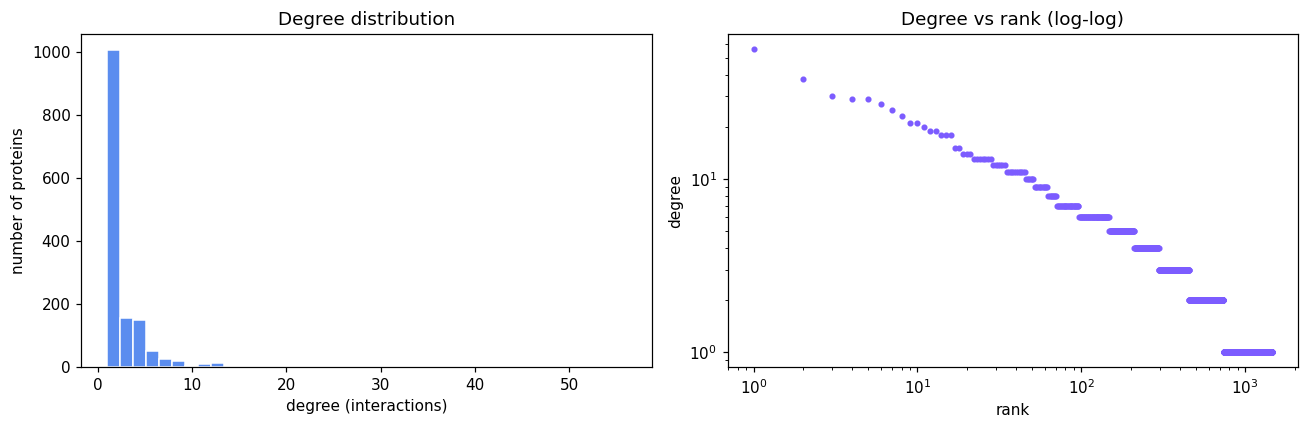

In [3]:
deg = np.array([d for _, d in G.degree()])
order = np.argsort(-deg)

print(f"Degree: min={deg.min()}, median={np.median(deg):.0f}, mean={deg.mean():.1f}, "
      f"max={deg.max()}  (very sparse: mean degree < 3)")
n_deg1 = int((deg == 1).sum())
print(f"Degree-1 nodes: {n_deg1} ({100*n_deg1/n_nodes:.0f}% of the network); "
      f"degree<=2: {int((deg <= 2).sum())} ({100*(deg <= 2).mean():.0f}%)")
print(f"Top hub proteins by degree: {[int(deg[i]) for i in order[:8]]}")
print(f"For comparison, Airports had ~10% degree-1 nodes; here it is far higher.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deg, bins=40, color="#5b8def", edgecolor="white")
axes[0].set_title("Degree distribution"); axes[0].set_xlabel("degree (interactions)")
axes[0].set_ylabel("number of proteins")
axes[1].loglog(np.arange(1, n_nodes + 1), deg[order], "o", ms=3, color="#7c5cff")
axes[1].set_title("Degree vs rank (log-log)")
axes[1].set_xlabel("rank"); axes[1].set_ylabel("degree")
plt.tight_layout(); plt.show()

**Prediction.** Half the network is degree-1 leaves — five times the Airports
proportion. If low-degree leaves drive the unnormalised-Laplacian degeneracy, we
should expect it here too, and possibly in a more severe form.

## 3. Choosing *k*

Same two-step spectral k-selection as the rest of the series: candidate shortlist
from the eigenvalue gaps, then **Silhouette** disambiguation (no ground truth).
The value is derived here, not hardcoded; the stored benchmark previously found
*k* = 3.

candidates = [2, 3, 6]  ->  two-step k = 3 (silhouette disambiguation)
Silhouette per candidate: {2: 0.501, 3: 0.615, 6: 0.55}


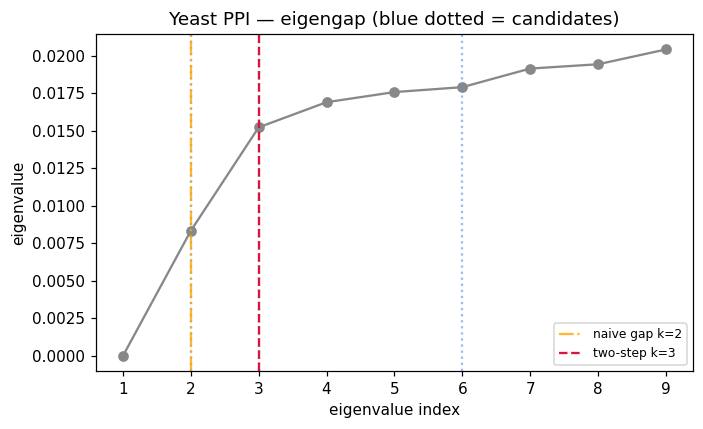

In [4]:
embeddings, timings = build_embeddings(A, n_components=10)
X_embed = embeddings["unnorm"]
A_dense = A.toarray()

spectral_sel = select_spectral_k(
    A_dense, X_embed,
    reference_fn=lambda kk: spectral_ng_jordan_weiss(A_dense, kk),
    ground_truth=None, top_n=3, k_min=2, k_max=8,
)
k = spectral_sel["best_k"]
print(f"candidates = {spectral_sel['candidates']}  ->  two-step k = {k} "
      f"({spectral_sel['criterion']} disambiguation)")
print(f"Silhouette per candidate: "
      f"{ {kk: round(v, 3) for kk, v in spectral_sel['scores'].items()} }")

ev = spectral_sel["eigenvalues"]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(range(1, len(ev) + 1), ev, "o-", color="#888")
for c in spectral_sel["candidates"]:
    ax.axvline(c, color="#5b8def", ls=":", alpha=0.6)
ax.axvline(spectral_sel["naive_suggested_k"], color="orange", ls="-.", alpha=0.8,
           label=f'naive gap k={spectral_sel["naive_suggested_k"]}')
ax.axvline(k, color="crimson", ls="--", label=f'two-step k={k}')
ax.set_title("Yeast PPI — eigengap (blue dotted = candidates)")
ax.set_xlabel("eigenvalue index"); ax.set_ylabel("eigenvalue")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Run all five algorithms

Same fixed seed and `n_init=10` convention as the previous notebooks.

In [5]:
algorithms = {
    "K-Means (embedding)":         lambda kk: kmeans_baseline(X_embed, kk),
    "Unnormalised SC":             lambda kk: unnormalised_spectral(A_dense, kk),
    "Shi-Malik SC":                lambda kk: spectral_shi_malik(A_dense, kk),
    "Ng-Jordan-Weiss SC":          lambda kk: spectral_ng_jordan_weiss(A_dense, kk),
    "Self-Tuning SC (embedding)":  lambda kk: self_tuning_spectral(X_embed, kk),
}
labels = {name: np.asarray(fn(k)) for name, fn in algorithms.items()}
for name, lab in labels.items():
    sizes = sorted(np.bincount(lab).tolist(), reverse=True)
    print(f"{name:28s} cluster sizes = {sizes}")

K-Means (embedding)          cluster sizes = [1434, 16, 8]
Unnormalised SC              cluster sizes = [1435, 15, 8]
Shi-Malik SC                 cluster sizes = [1436, 14, 8]
Ng-Jordan-Weiss SC           cluster sizes = [1202, 192, 64]
Self-Tuning SC (embedding)   cluster sizes = [1330, 66, 62]


## 4b. Degenerate split check

Following the Airports Section 4b diagnostic proactively: do the unnormalised
methods degenerate here, and if so, in what form? Section 4 already hints that the
sizes are lop-sided — this cell characterises it.

In [6]:
import networkx as nx
deg = np.array([d for _, d in G.degree()])
mu = X_embed.mean(axis=0)
dcen = np.linalg.norm(X_embed - mu, axis=1)
arts = set(nx.articulation_points(G))

for name in ["K-Means (embedding)", "Unnormalised SC"]:
    sizes = sorted(np.bincount(labels[name]).tolist(), reverse=True)
    kind = "single-node isolation" if min(sizes) == 1 else "small fragment(s), not a lone node"
    print(f"{name:20s} sizes={sizes}  smallest cluster = {min(sizes)} nodes ({kind})")

print("\nProfile of the small (fragment) clusters:")
for name in ["K-Means (embedding)", "Unnormalised SC"]:
    lab = labels[name]
    for c in np.unique(lab):
        idx = np.where(lab == c)[0]
        if len(idx) < 100:
            ds = deg[idx]
            n_art = sum(1 for i in idx if nodes[i] in arts)
            print(f"  {name:20s} fragment of {len(idx):2d} nodes: degree {ds.min()}-{ds.max()} "
                  f"(mean {ds.mean():.1f}); {int((ds == 1).sum())} degree-1; {n_art} articulation points")

print(f"\nEmbedding: {int((dcen > 0.1).sum())} nodes lie far (>0.1) from the centroid, "
      f"vs exactly 1 on Airports (TVI).")
print(f"Degree-1 nodes: {int((deg == 1).sum())} ({100*(deg == 1).mean():.0f}% of the network).")

K-Means (embedding)  sizes=[1434, 16, 8]  smallest cluster = 8 nodes (small fragment(s), not a lone node)
Unnormalised SC      sizes=[1435, 15, 8]  smallest cluster = 8 nodes (small fragment(s), not a lone node)

Profile of the small (fragment) clusters:
  K-Means (embedding)  fragment of  8 nodes: degree 1-4 (mean 1.9); 4 degree-1; 4 articulation points
  K-Means (embedding)  fragment of 16 nodes: degree 1-7 (mean 2.1); 9 degree-1; 5 articulation points
  Unnormalised SC      fragment of  8 nodes: degree 1-4 (mean 1.9); 4 degree-1; 4 articulation points
  Unnormalised SC      fragment of 15 nodes: degree 1-6 (mean 2.5); 5 degree-1; 5 articulation points

Embedding: 182 nodes lie far (>0.1) from the centroid, vs exactly 1 on Airports (TVI).
Degree-1 nodes: 722 (50% of the network).


### Conclusion — same cause, different shape

The unnormalised methods **do** degenerate, but not as a single isolated node.
K-Means and Unnormalised SC (and, unusually, Shi-Malik too) return a **giant
cluster plus a couple of tiny fragments** ($\approx [1434, 16, 8]$) rather than
Airports' clean $[726, 1]$ singleton. The fragments are small groups of very
low-degree proteins (degree 1-7).

The reason is the same degree-imbalance mechanism, scaled up. On Airports one leaf
(TVI) was uniquely extreme, so the leading eigenvector isolated exactly it. Here
**half the network is degree-1** and the "outlier mass" is spread across ~180
near-equivalent low-degree nodes, so no single node dominates an eigenvector —
instead the low-lying eigenvectors localise on small clusters of leaves, and
K-Means peels those off as tiny fragments. It is the same failure (degree
imbalance corrupting the unnormalised embedding), expressed as fragmentation
rather than single-node isolation because the leaf population is so large.

Notably **Shi-Malik degenerates here as well**, unlike on Airports. Only
**Ng-Jordan-Weiss** avoids it — its extra step of *row-normalising* the embedding
(projecting every node onto the unit sphere) is what neutralises the magnitude
differences the leaves create, which the plain random-walk normalisation does
not.

## 5. Evaluation under three embeddings

Silhouette and Davies-Bouldin under the three neutral embeddings. As on Airports
we **load `results/network_eval_yeast.json`** (recomputing only if the derived *k*
differs from the stored *k* = 3). The proxy-era notes suggested Yeast's ranking
was fully stable across embeddings (Spearman = 1.0) — we confirm that with the
*k* derived above.

In [7]:
res_path = _repo / "results" / "network_eval_yeast.json"
if k == 3 and res_path.exists():
    stored = json.load(open(res_path))
    print(f"Loaded precomputed results from {res_path.name} (k = {stored['k']}, "
          f"shortest-path timing {stored.get('shortest_path_seconds')} s).")
    df = pd.DataFrame(stored["table"])
else:
    print(f"Derived k = {k} differs from the stored run; recomputing.")
    df, _t = evaluate_multi_embedding(A, labels, n_components=10)

print("\nSilhouette Score by embedding (higher is better):")
print(format_comparison_table(df, "silhouette").to_string(index=False))
print("\nDavies-Bouldin Index by embedding (lower is better):")
print(format_comparison_table(df, "davies_bouldin").to_string(index=False))

for metric in ("silhouette", "davies_bouldin"):
    cons = ranking_consistency(df, metric=metric)
    print("\n" + consistency_verdict(cons, "yeast"))
    print(f"  Spearman(rank) between embeddings: "
          f"{ {kk: round(v, 2) for kk, v in cons['spearman'].items()} }")

Loaded precomputed results from network_eval_yeast.json (k = 3, shortest-path timing 0.251 s).

Silhouette Score by embedding (higher is better):
                 algorithm  silhouette_unnorm  silhouette_sym  silhouette_shortest_path
       K-Means (embedding)             0.7510          0.7413                    0.2619
           Unnormalised SC             0.7519          0.7440                    0.3212
              Shi-Malik SC             0.7588          0.7520                    0.3223
        Ng-Jordan-Weiss SC             0.6153          0.5877                    0.1901
Self-Tuning SC (embedding)            -0.4415         -0.4361                   -0.0649

Davies-Bouldin Index by embedding (lower is better):
                 algorithm  davies_bouldin_unnorm  davies_bouldin_sym  davies_bouldin_shortest_path
       K-Means (embedding)                 0.3160              0.4798                        0.7166
           Unnormalised SC                 0.3594              0.5037   

## 6. Consistency and circularity

In [8]:
sil = df.set_index("algorithm")
km = sil.loc["K-Means (embedding)"]
print("K-Means Silhouette across embeddings:")
print(f"   unnormalised = {km['silhouette_unnorm']:+.3f}   "
      f"symmetric = {km['silhouette_sym']:+.3f}   "
      f"shortest-path = {km['silhouette_shortest_path']:+.3f}")
csil = ranking_consistency(df, "silhouette")
print(f"\nSilhouette winner per embedding: {csil['winners']}")
print(f"Silhouette rank correlation unnorm~sym = {csil['spearman']['unnorm~sym']:+.2f}")

K-Means Silhouette across embeddings:
   unnormalised = +0.751   symmetric = +0.741   shortest-path = +0.262

Silhouette winner per embedding: {'unnorm': 'Shi-Malik SC', 'sym': 'Shi-Malik SC', 'shortest_path': 'Shi-Malik SC'}
Silhouette rank correlation unnorm~sym = +1.00


### Is fit-space circularity a problem here?

Much less than on Airports. There, K-Means swung from Silhouette $+0.97$ in its
fit-space (unnormalised) to $-0.73$ in the symmetric embedding — a $1.7$-point
flip driven by the single-node split. Here K-Means scores $\approx +0.75$ under
*both* the unnormalised and symmetric embeddings: the fragment split is small
enough that it is rewarded similarly in either space, so there is no anti-
correlation and the **ranking is fully stable across all three embeddings
(Spearman = 1.0)**.

So for Yeast specifically, embedding choice is not a source of instability — a
genuinely reassuring property. The important caveat is that *stability is not
correctness*: all three embeddings agree, but they agree on ranking **Shi-Malik**
(a near-degenerate giant+fragments split) first, while the method that actually
recovers modular structure (Ng-Jordan-Weiss, Section 9) scores lower. Internal
indices being self-consistent does not make them right.

## 7. Davies-Bouldin outlier check

Same scan as Airports/Synthetic: any Davies-Bouldin value exceeding **3x the
table median**. On rings this exposed a 14x centroid-collapse artefact; on
Airports nothing exceeded 3x.

In [9]:
db_vals = df[[f"davies_bouldin_{e}" for e in EMBEDDINGS]].to_numpy().ravel()
median_db = float(np.median(db_vals))
print(f"Davies-Bouldin: table median = {median_db:.3f}, "
      f"maximum = {db_vals.max():.3f} ({db_vals.max()/median_db:.1f}x median)")

flags = [(row["algorithm"], e, row[f"davies_bouldin_{e}"])
         for _, row in df.iterrows() for e in EMBEDDINGS
         if row[f"davies_bouldin_{e}"] > 3 * median_db]
for a, e, v in sorted(flags, key=lambda t: -t[2]):
    print(f"  >3x: {a} / {e} = {v:.3f} ({v/median_db:.1f}x median)")

# distinguish a genuine centroid-collapse artefact from merely spread-out clusters
from sklearn.metrics import davies_bouldin_score
def min_centroid_distance(E, lab):
    cs = np.array([E[lab == c].mean(0) for c in np.unique(lab)])
    return min(np.linalg.norm(cs[i] - cs[j])
               for i in range(len(cs)) for j in range(i + 1, len(cs)))
worst_algo, worst_emb, _ = max(flags, key=lambda t: t[2])
print(f"\nMechanism check on the worst offender ({worst_algo} / {worst_emb}):")
print(f"  min inter-centroid distance = "
      f"{min_centroid_distance(embeddings[worst_emb], labels[worst_algo]):.4f} "
      f"(< 0.01 would indicate a rings-style centroid collapse)")

Davies-Bouldin: table median = 0.626, maximum = 4.674 (7.5x median)
  >3x: Self-Tuning SC (embedding) / sym = 4.674 (7.5x median)
  >3x: Self-Tuning SC (embedding) / shortest_path = 3.667 (5.9x median)
  >3x: Self-Tuning SC (embedding) / unnorm = 3.665 (5.9x median)
  >3x: Ng-Jordan-Weiss SC / shortest_path = 2.394 (3.8x median)
  >3x: Ng-Jordan-Weiss SC / sym = 2.160 (3.4x median)
  >3x: Ng-Jordan-Weiss SC / unnorm = 2.111 (3.4x median)

Mechanism check on the worst offender (Self-Tuning SC (embedding) / sym):
  min inter-centroid distance = 0.0092 (< 0.01 would indicate a rings-style centroid collapse)


Unlike Airports (nothing above 3x), several Yeast values do exceed the
threshold — up to ~7.5x for **Self-Tuning SC**, plus **Ng-Jordan-Weiss** at
~3-4x. But none approach the synthetic `rings` 14x blow-up, and the mechanisms
differ: Self-Tuning's high value is partly a mild centroid-collapse (two of its
centroids sit very close), whereas Ng-Jordan-Weiss's elevated Davies-Bouldin
reflects **genuinely spread-out clusters** (its centroids are well separated) —
the price of committing to a real, non-trivial three-way partition rather than a
compact fragment split.

## 8. Visualisation

Yeast PPI has no natural spatial coordinates, so there is no geographic map — we
show only the **force-directed network layout** (as in Airports Section 9), nodes
coloured by cluster, for all five algorithms, edges thin and transparent.

Force-directed layout of 1458 proteins and 1948 interactions.


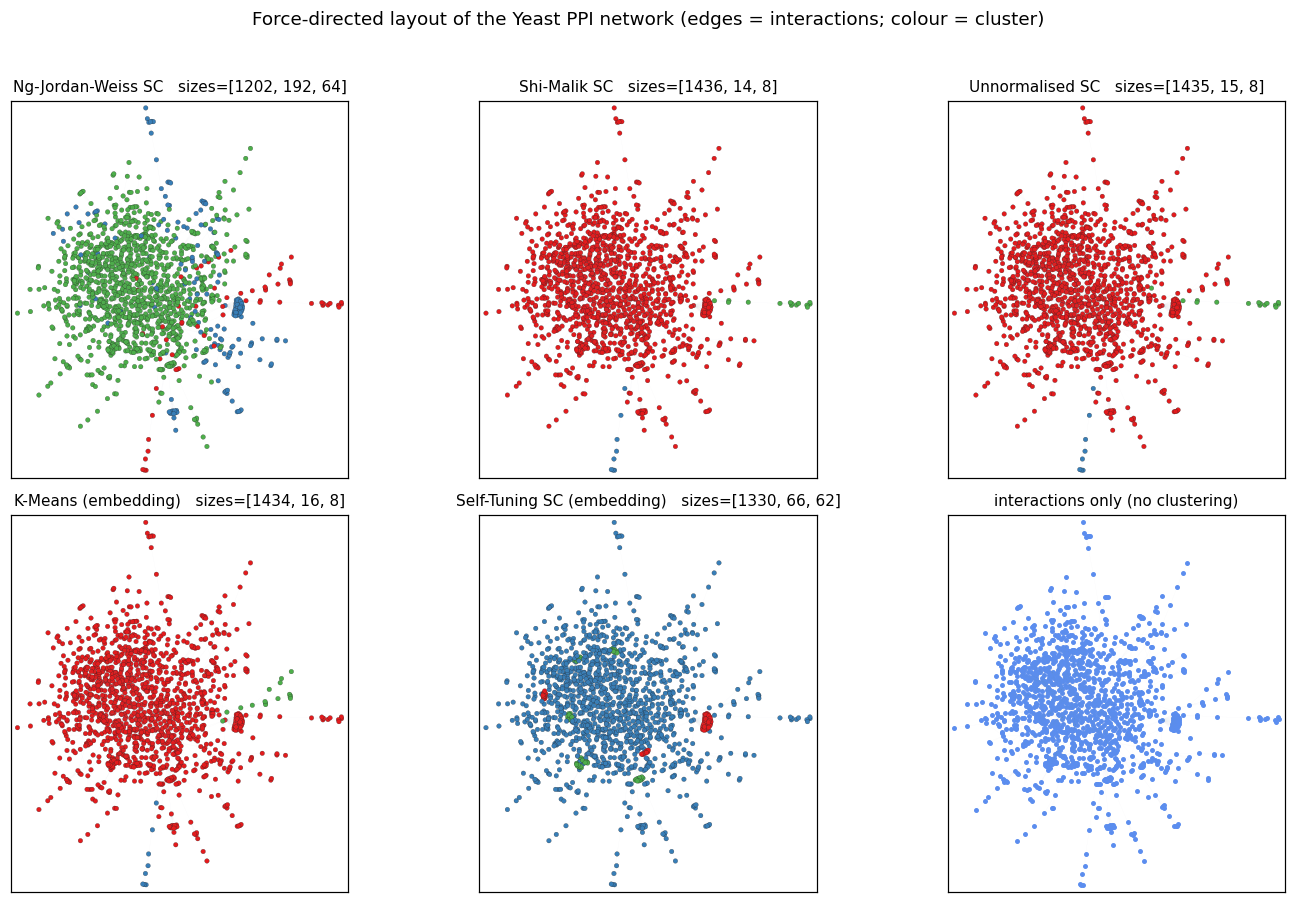

In [10]:
import networkx as nx
from matplotlib.collections import LineCollection

PALETTE = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
           "#00ced1", "#f781bf", "#a65628"]
cc = lambda lab: [PALETTE[int(c) % len(PALETTE)] for c in lab]

idx = {nd: i for i, nd in enumerate(nodes)}
pos = nx.spring_layout(G, seed=SEED, iterations=60)
P = np.array([pos[nodes[i]] for i in range(len(nodes))])
segs = np.array([[P[idx[u]], P[idx[v]]] for u, v in G.edges()])
print(f"Force-directed layout of {len(nodes)} proteins and {len(segs)} interactions.")

panels = ["Ng-Jordan-Weiss SC", "Shi-Malik SC", "Unnormalised SC",
          "K-Means (embedding)", "Self-Tuning SC (embedding)", None]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
for ax, algo in zip(axes.ravel(), panels):
    ax.add_collection(LineCollection(segs, colors="#9aa2b4", linewidths=0.15, alpha=0.06))
    if algo is None:
        ax.scatter(P[:, 0], P[:, 1], s=5, c="#5b8def")
        ax.set_title("interactions only (no clustering)", fontsize=10)
    else:
        sizes = sorted(np.bincount(labels[algo]).tolist(), reverse=True)
        ax.scatter(P[:, 0], P[:, 1], s=9, c=cc(labels[algo]),
                   edgecolor="#222222", linewidth=0.15)
        ax.set_title(f"{algo}   sizes={sizes}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal"); ax.margins(0.02)
fig.suptitle("Force-directed layout of the Yeast PPI network "
             "(edges = interactions; colour = cluster)", y=1.02)
plt.tight_layout(); plt.show()

## 9. Findings

Because the `bio-yeast` file provides only **anonymous integer node IDs** (no gene
or protein names), a name-level biological sanity check against known yeast
complexes — the analogue of Airports' geographic check — is not possible. Instead
we use **modularity** as a structural proxy: it measures whether a partition's
clusters are internally dense communities, which is exactly what a real functional
module should be.

In [11]:
from networkx.algorithms.community import modularity
idxmap = {nd: i for i, nd in enumerate(nodes)}
print("Modularity Q of each partition (higher = denser communities; "
      "~0 = no better than random):")
rows = []
for name, lab in labels.items():
    comms = {}
    for node in G.nodes():
        comms.setdefault(int(lab[idxmap[node]]), set()).add(node)
    Q = modularity(G, list(comms.values()))
    rows.append((name, Q, sorted(np.bincount(lab).tolist(), reverse=True)))
for name, Q, sizes in sorted(rows, key=lambda t: -t[1]):
    print(f"  {name:28s} Q = {Q:+.3f}   sizes = {sizes}")

Modularity Q of each partition (higher = denser communities; ~0 = no better than random):
  Ng-Jordan-Weiss SC           Q = +0.242   sizes = [1202, 192, 64]
  Unnormalised SC              Q = +0.025   sizes = [1435, 15, 8]
  Shi-Malik SC                 Q = +0.024   sizes = [1436, 14, 8]
  K-Means (embedding)          Q = +0.023   sizes = [1434, 16, 8]
  Self-Tuning SC (embedding)   Q = -0.002   sizes = [1330, 66, 62]


### Summary

- **Best algorithm — and internal indices disagree with structure.** By
  Silhouette, **Shi-Malik** "wins" under all three embeddings — but Section 4b
  showed that is a near-degenerate giant+fragments split. The modularity check
  tells the real story: only **Ng-Jordan-Weiss** finds genuine community structure
  (**Q ≈ 0.24**), while every other method sits at **Q ≈ 0.02 or below** — no
  better than random. As on Airports, the method that internal indices crown is
  not the one that finds real structure; here it takes modularity (not Silhouette)
  to see it.
- **Are the results trustworthy?** The *ranking* is stable across embeddings
  (Spearman = 1.0), so unlike Airports there is no embedding-instability caveat —
  but that stability masks a wrong answer, since the stable winner is a
  fragment split. The trustworthy, defensible result is Ng-Jordan-Weiss's modular
  partition, supported by modularity rather than Silhouette.
- **Biological interpretation.** With anonymous node IDs we cannot name the
  clusters, but Ng-Jordan-Weiss's high modularity means its ~$[1202, 192, 64]$
  partition corresponds to genuinely dense interaction sub-networks — consistent
  with the expectation that a PPI network decomposes into functional modules.
- **Versus Airports (degree normalisation).** The Airports degree-imbalance story
  holds and intensifies: with **50% degree-1 nodes** (vs ~10% on Airports) the
  unnormalised methods degenerate more severely, and even Shi-Malik succumbs — only
  Ng-Jordan-Weiss's row-normalisation survives. This is stronger evidence that
  degree normalisation, not outlier removal, is the right remedy on leaf-heavy
  graphs.
- **Versus the synthetic data (Self-Tuning).** Self-Tuning SC is again the
  worst — negative Silhouette and **Q ≈ 0** (no community structure) — matching its
  poor showing on Airports and Facebook and contradicting its strong synthetic
  performance. Its local-scaling affinity, tuned for Euclidean point clouds, does
  not transfer to sparse biological graphs.

## 10. Headline comparison: Shi-Malik vs Ng-Jordan-Weiss

The notebook's central finding is that **Shi-Malik** is favoured by Silhouette but
is a near-degenerate giant+fragments split, whereas **Ng-Jordan-Weiss** is
favoured by modularity and is structurally genuine. The two figures below make
that contrast visible directly from the graph, rather than from the force-directed
hairball (Section 8, kept as-is). Both compare the *same* two partitions with the
same titles (algorithm, modularity $Q$, and Silhouette in the unnormalised
embedding).

In [12]:
from sklearn.metrics import silhouette_score
from networkx.algorithms.community import modularity as nx_modularity

_idxmap = {nd: i for i, nd in enumerate(nodes)}
def _Q(lab):
    comms = {}
    for nd in G.nodes():
        comms.setdefault(int(lab[_idxmap[nd]]), set()).add(nd)
    return nx_modularity(G, list(comms.values()))
def _sil(lab):
    return silhouette_score(embeddings["unnorm"], lab)

pair = {"Shi-Malik SC": labels["Shi-Malik SC"],
        "Ng-Jordan-Weiss SC": labels["Ng-Jordan-Weiss SC"]}
scores = {nm: (_Q(lab), _sil(lab)) for nm, lab in pair.items()}
print("headline pair:")
for nm, (q, s) in scores.items():
    print(f"  {nm:20s} Q={q:+.3f}  Silhouette={s:+.3f}  "
          f"sizes={sorted(np.bincount(pair[nm]).tolist(), reverse=True)}")

headline pair:
  Shi-Malik SC         Q=+0.024  Silhouette=+0.759  sizes=[1436, 14, 8]
  Ng-Jordan-Weiss SC   Q=+0.242  Silhouette=+0.615  sizes=[1202, 192, 64]


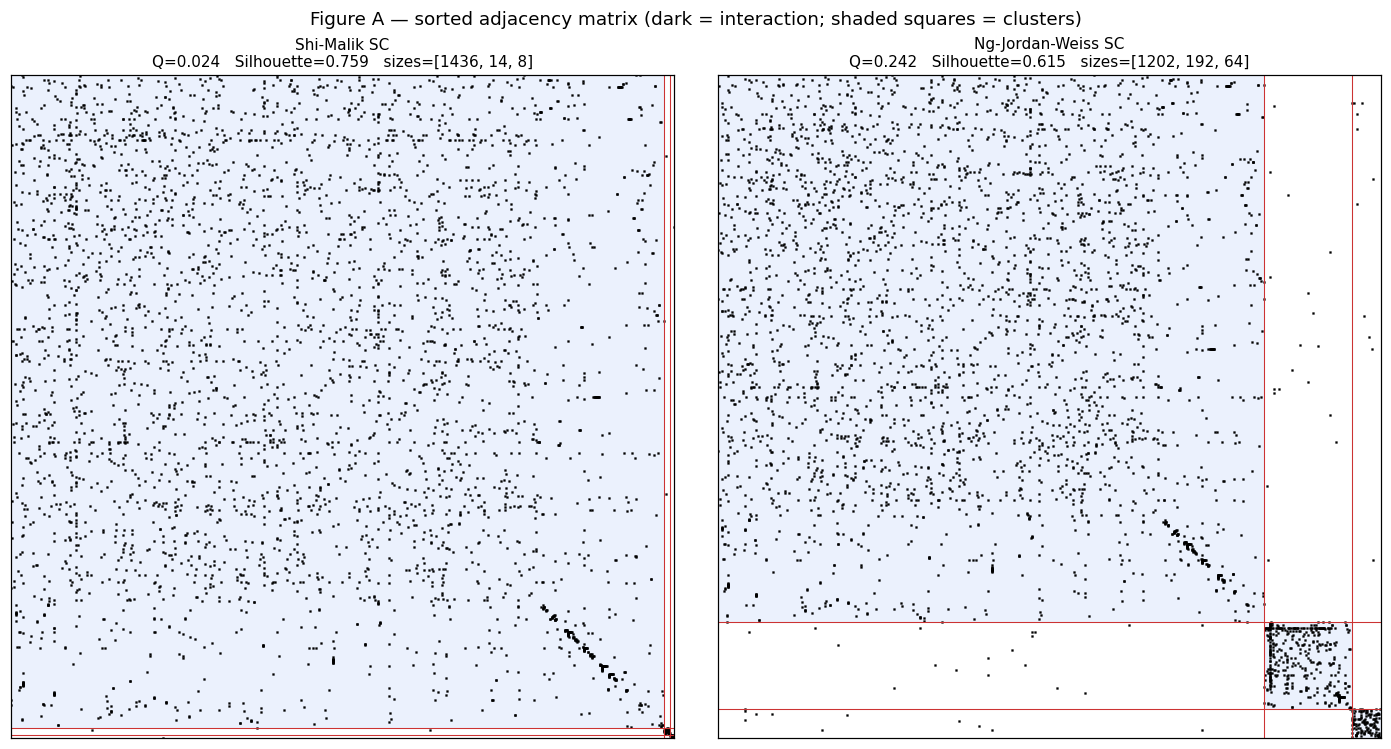

In [13]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(13, 6.7))
for ax, (nm, lab) in zip(axes, pair.items()):
    # order clusters largest-first; within a cluster keep node-index order (stable)
    order = sorted(np.unique(lab), key=lambda c: -(lab == c).sum())
    perm = np.concatenate([np.where(lab == c)[0] for c in order])
    sizes = [int((lab == c).sum()) for c in order]
    Aperm = A_dense[np.ix_(perm, perm)]

    ax.spy(Aperm, markersize=0.5, color="black", aspect="equal", zorder=2)
    b = np.cumsum([0] + sizes)
    for s0, s1, sz in zip(b[:-1], b[1:], sizes):
        ax.add_patch(Rectangle((s0, s0), sz, sz, facecolor="#5b8def",
                               alpha=0.12, edgecolor="none", zorder=0))
    for x in b[1:-1]:
        ax.axhline(x, color="#cc3333", lw=0.7); ax.axvline(x, color="#cc3333", lw=0.7)
    q, s = scores[nm]
    ax.set_title(f"{nm}\nQ={q:.3f}   Silhouette={s:.3f}   sizes={sizes}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Figure A — sorted adjacency matrix "
             "(dark = interaction; shaded squares = clusters)", y=1.01)
plt.tight_layout(); plt.show()

*Figure A.* Rows and columns are reordered so same-cluster proteins are
contiguous (largest cluster first). High modularity should show as **dense blocks
on the diagonal with a sparse off-diagonal**; a near-degenerate split as **one
dominant block with barely-visible fragments**. Ng-Jordan-Weiss shows exactly the
former — its two smaller clusters are visible as denser blocks in the top-left,
with conspicuously empty (white) off-diagonal bands separating them from the giant
component. Shi-Malik is a single block filling almost the whole matrix, its two
tiny fragments invisible in the corner.

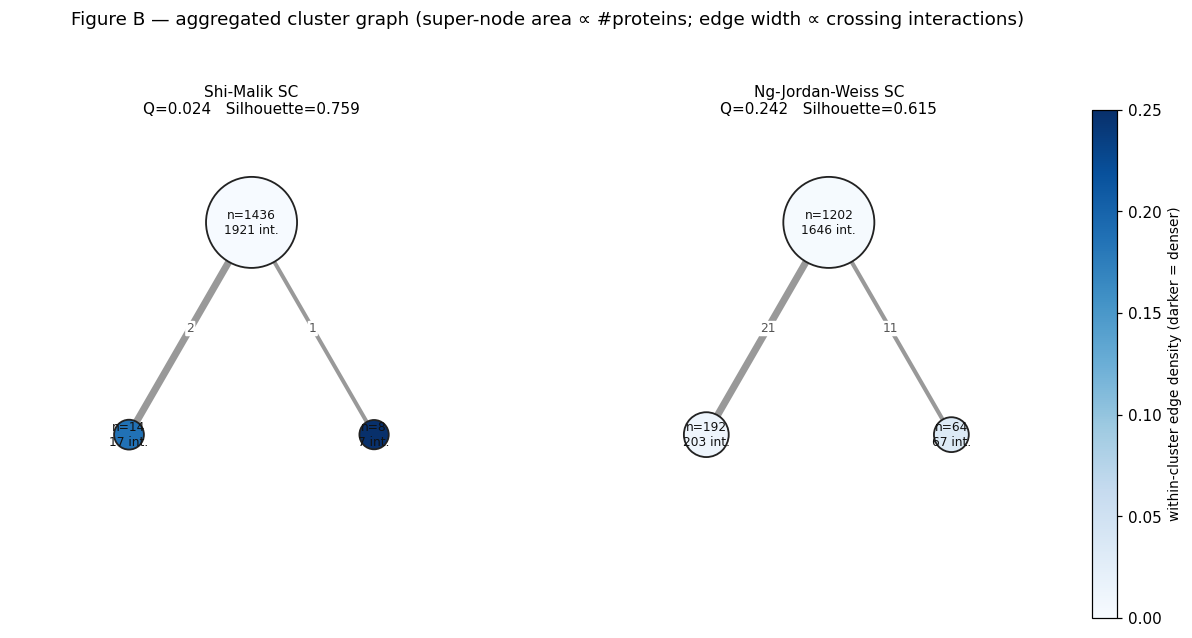

In [14]:
import networkx as nx

def _aggregate(lab):
    ks = list(np.unique(lab)); K = len(ks); pos_of = {k: i for i, k in enumerate(ks)}
    sizes = np.array([int((lab == k).sum()) for k in ks])
    within = np.zeros(K); between = np.zeros((K, K))
    coo = A.tocoo()
    for i, j in zip(coo.row, coo.col):
        if i < j:
            a, b = pos_of[lab[i]], pos_of[lab[j]]
            if a == b: within[a] += 1
            else: between[a, b] += 1; between[b, a] += 1
    order = np.argsort(-sizes)
    return sizes[order], within[order], between[np.ix_(order, order)]

agg = {nm: _aggregate(lab) for nm, lab in pair.items()}
# comparable colour scale for internal density across both panels
def _density(sizes, within):
    return within / np.maximum(sizes * (sizes - 1) / 2, 1)
vmax = max(_density(s, w).max() for s, w, _ in agg.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (nm, lab) in zip(axes, pair.items()):
    sizes, within, between = agg[nm]; K = len(sizes)
    ang = np.linspace(0, 2 * np.pi, K, endpoint=False) + np.pi / 2
    P = np.c_[np.cos(ang), np.sin(ang)]
    for i in range(K):
        for j in range(i + 1, K):
            if between[i, j] > 0:
                ax.plot(*zip(P[i], P[j]), color="#999999",
                        lw=0.6 + 4 * between[i, j] / max(between.max(), 1), zorder=1)
                m = (P[i] + P[j]) / 2
                ax.text(*m, f"{int(between[i, j])}", fontsize=8, color="#555",
                        ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none"))
    dens = _density(sizes, within)
    sizetext = 350 + 3200 * sizes / sizes.max()
    sc = ax.scatter(P[:, 0], P[:, 1], s=sizetext, c=dens, cmap="Blues",
                    vmin=0, vmax=vmax, edgecolor="#222222", linewidth=1.2, zorder=2)
    for i in range(K):
        ax.annotate(f"n={sizes[i]}\n{int(within[i])} int.", P[i], ha="center", va="center",
                    fontsize=8, zorder=3, color="#111111")
    q, s = scores[nm]
    ax.set_title(f"{nm}\nQ={q:.3f}   Silhouette={s:.3f}", fontsize=10)
    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7); ax.set_aspect("equal"); ax.axis("off")

cb = fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.02)
cb.set_label("within-cluster edge density (darker = denser)", fontsize=9)
fig.suptitle("Figure B — aggregated cluster graph "
             "(super-node area ∝ #proteins; edge width ∝ crossing interactions)", y=1.03)
plt.show()

*Figure B.* Each cluster is collapsed to a super-node (area proportional
to the number of proteins), edges are drawn with width proportional to the number
of interactions crossing between clusters and labelled with that count, and the
super-node shade encodes internal edge density. Shi-Malik is one giant super-node
holding almost every interaction (1,921 of 1,948 internal) with two dangling
fragments — a single community with specks attached. Ng-Jordan-Weiss splits into
three genuinely sized, internally-connected communities (≈1,202 / 192 / 64
proteins, each with substantial internal edges) joined by only a handful of
crossing interactions — the signature of real modular structure, and why its
modularity is ten times higher despite a lower Silhouette.